In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils.two_state_hmm import *
from utils.cvxpy_portfolio import *


## Set Up DataFrames

In [2]:
insampleRet = pd.read_csv("data/etf_returns_insample.csv", index_col=0, parse_dates=True)
outsampleRet = pd.read_csv("data/etf_returns_outsample.csv", index_col=0, parse_dates=True)
prices = pd.read_csv("data/etf_prices.csv", index_col=0, parse_dates=True) 

In [3]:
insampleRet

,EFA,GLD,HYG,IWM,LQD,QQQ,SPY,TLT
Date,,,,,,,,
2007-04-12,0.006655,-0.001343,0.000671,0.006702,0.001503,0.007886,0.004434,0.000228
2007-04-13,0.003311,0.012609,-0.001821,0.006412,-0.001692,0.002018,0.004552,-0.003094
2007-04-16,0.010497,0.008221,-0.000384,0.013673,0.000847,0.009140,0.009451,0.005495
2007-04-17,0.000126,-0.005865,-0.000480,-0.003036,0.005436,0.002217,0.002655,0.005578
2007-04-18,-0.000377,0.005573,0.000289,-0.005854,0.000282,-0.003327,0.001222,0.004982
...,...,...,...,...,...,...,...,...
2018-12-24,-0.011708,0.010891,-0.007506,-0.019588,-0.002317,-0.025110,-0.026778,0.004958
2018-12-26,0.022938,-0.003004,0.016687,0.046943,-0.000803,0.060567,0.049290,-0.010774
2018-12-27,0.002916,0.007576,-0.000617,0.004160,0.000000,0.003862,0.007648,0.000166


In [4]:
outsampleRet

,EFA,GLD,HYG,IWM,LQD,QQQ,SPY,TLT
Date,,,,,,,,
2019-01-02,-0.002044,0.000660,-0.001357,0.005660,0.003098,0.004011,0.001040,0.005254
2019-01-03,-0.009076,0.009025,0.000494,-0.018059,0.000442,-0.033217,-0.024152,0.011315
2019-01-04,0.030161,-0.008119,0.016644,0.036673,-0.000619,0.041895,0.032947,-0.011643
2019-01-07,0.003832,0.003453,0.009664,0.017342,0.000089,0.011835,0.007854,-0.002952
2019-01-08,0.006464,-0.002712,0.006470,0.015215,0.002207,0.009005,0.009351,-0.002632
...,...,...,...,...,...,...,...,...
2024-12-23,0.006503,-0.004720,-0.002676,-0.002301,-0.002902,0.009695,0.005970,-0.009215
2024-12-24,0.003566,0.001990,0.003185,0.008903,0.003089,0.013469,0.011054,0.004220
2024-12-26,0.004734,0.006728,0.002541,0.010199,0.000934,-0.000680,0.000067,-0.000569


In [5]:
prices

,EFA,GLD,HYG,IWM,LQD,QQQ,SPY,TLT
Date,,,,,,,,
2007-04-11,44.219479,67.080002,32.021992,62.195061,50.453194,37.935265,101.382843,48.607006
2007-04-12,44.514740,66.989998,32.043472,62.613289,50.529099,38.235615,101.833389,48.618099
2007-04-13,44.662357,67.839996,31.985174,63.016041,50.443672,38.312836,102.297989,48.467922
2007-04-16,45.133625,68.400002,31.972891,63.883572,50.486397,38.664623,103.269440,48.734982
2007-04-17,45.139305,68.000000,31.957541,63.689892,50.761600,38.750446,103.544014,49.007565
...,...,...,...,...,...,...,...,...
2024-12-23,72.980751,240.960007,72.909065,218.558975,100.825233,519.576416,586.186646,82.844894
2024-12-24,73.241432,241.440002,73.141632,220.513489,101.137184,526.621826,592.702087,83.195229
2024-12-26,73.589012,243.070007,73.327713,222.773987,101.231682,526.264038,592.741577,83.147881


## Fit Two-State HMM on SPY

In [6]:
regimeRetIn = insampleRet[["SPY"]]
model, stateDf = fit_two_state_hmm(regimeRetIn)
stateDf = relabel_states_by_vol_two_state(stateDf)
summary = summarize_states(model, stateDf)

print("\nMeans learned by model:")
print(model.means_)

print("\nCovariances learned by model:")
print(model.covars_)

print("\nTransition matrix:")
print(model.transmat_)

print("\nState summary:")
print(summary)

plot_regimes(stateDf, output_dir="results", plot_id="insample_two_state_base")

Model is not converging.  Current: 9467.347159764573 is not greater than 9467.527147615547. Delta is -0.17998785097370273



Means learned by model:
[[ 0.00086539]
 [-0.00162136]]

Covariances learned by model:
[[[5.51659038e-05]]

 [[5.02319659e-04]]]

Transition matrix:
[[0.98760041 0.01239959]
 [0.03854429 0.96145571]]

State summary:
   state  n_obs  fraction  mean_return  volatility  annualized_mean_approx  \
0      0   2273  0.769986     0.000848    0.007252                0.213626   
1      1    679  0.230014    -0.001669    0.022396               -0.420668   

   annualized_vol_approx  
0               0.115128  
1               0.355519  


Try to fit another time here with standardization to see if convergence warning can be resolved

In [7]:
modelScaled, stateDfScaled = fit_two_state_hmm_scaled(regimeRetIn)
stateDfScaled = relabel_states_by_vol_two_state(stateDfScaled)
summaryScaled = summarize_states(modelScaled, stateDfScaled)

print("\nMeans learned by model (Scaled):")
print(modelScaled.means_)

print("\nCovariances learned by model (Scaled):")
print(modelScaled.covars_)

print("\nTransition matrix:")
print(modelScaled.transmat_)

print("\nState summary:")
print(summaryScaled)

plot_regimes(stateDfScaled, output_dir="results", plot_id="scaled")


Means learned by model (Scaled):
[[ 0.05983889]
 [-0.13101423]]

Covariances learned by model (Scaled):
[[[0.25765784]]

 [[2.60033778]]]

Transition matrix:
[[0.97801908 0.02198092]
 [0.04757044 0.95242956]]

State summary:
   state  n_obs  fraction  mean_return  volatility  annualized_mean_approx  \
0      0   2050  0.694444     0.000949    0.006426                0.239108   
1      1    902  0.305556    -0.001277    0.020406               -0.321766   

   annualized_vol_approx  
0               0.102006  
1               0.323929  


Convergence issue seems to be fixed with standardization, will be using scaled model from this point onward. Visually, there doesn't seem to be much difference, but the calculated values are slightly different.

### Display Intermediate Results

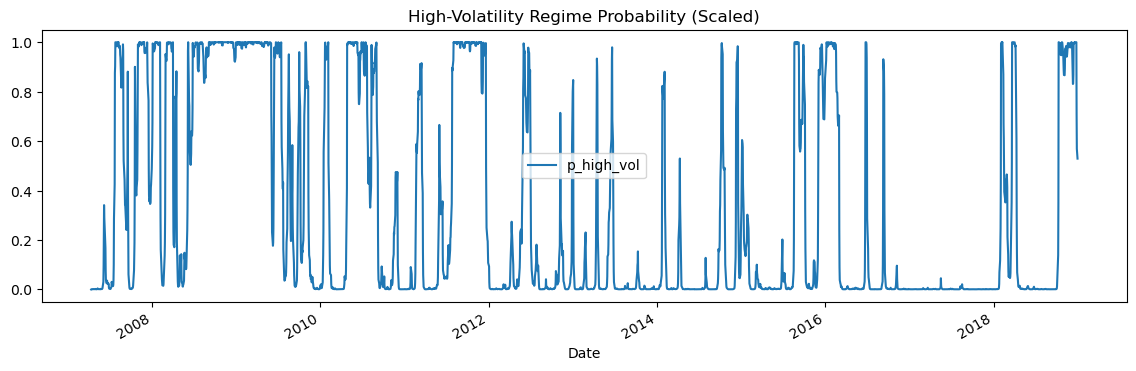

In [8]:
stateDfScaled[["p_high_vol"]].plot(figsize=(14, 4), title="High-Volatility Regime Probability (Scaled)")
plt.show()

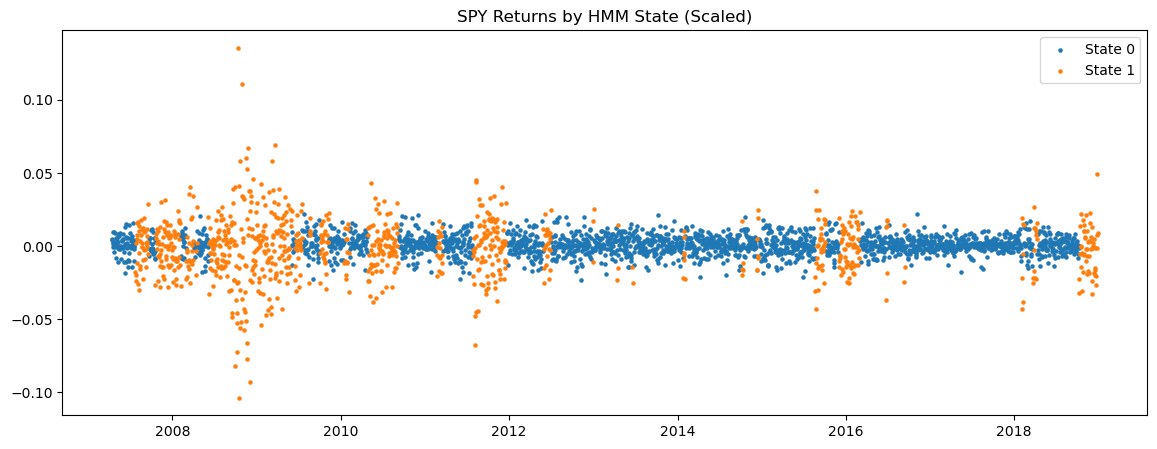

In [9]:
plt.figure(figsize=(14, 5))
for s in [0, 1]:
    mask = stateDfScaled["state"] == s
    plt.scatter(
        stateDfScaled.index[mask],
        stateDfScaled.loc[mask, "SPY_ret"],
        s=5,
        label=f"State {s}"
    )
plt.legend()
plt.title("SPY Returns by HMM State (Scaled)")
plt.show()

Checking 2008-2009 period to see if majority is truly classified as high-volatility, as we would expect.

In [10]:
stateDfScaled.loc["2008-01-01":"2009-06-30", ["SPY_ret", "state", "p_high_vol"]]

,SPY_ret,state,p_high_vol
Date,,,
2008-01-02,-0.008793,1,0.579020
2008-01-03,-0.000483,1,0.676568
2008-01-04,-0.024812,1,0.995013
2008-01-07,-0.000849,1,0.986133
2008-01-08,-0.016280,1,0.989315
...,...,...,...
2009-06-24,0.008581,1,0.983093
2009-06-25,0.021516,1,0.990555
2009-06-26,-0.002610,1,0.960123


In [11]:
stateDfScaled.loc["2008-01-01":"2009-06-30", ["state"]].value_counts()

state
1        312
0         65
Name: count, dtype: int64

## Label ETFs and Report Regime Metrics

In [12]:
#State 0: lower volatility, State 1: higher volatility
regimeLabels = stateDfScaled[["state"]].copy()
inRetLabeled = insampleRet.join(regimeLabels, how="inner")

display(inRetLabeled.head())

,EFA,GLD,HYG,IWM,LQD,QQQ,SPY,TLT,state
Date,,,,,,,,,
2007-04-12,0.006655,-0.001343,0.000671,0.006702,0.001503,0.007886,0.004434,0.000228,0
2007-04-13,0.003311,0.012609,-0.001821,0.006412,-0.001692,0.002018,0.004552,-0.003094,0
2007-04-16,0.010497,0.008221,-0.000384,0.013673,0.000847,0.009140,0.009451,0.005495,0
2007-04-17,0.000126,-0.005865,-0.000480,-0.003036,0.005436,0.002217,0.002655,0.005578,0
2007-04-18,-0.000377,0.005573,0.000289,-0.005854,0.000282,-0.003327,0.001222,0.004982,0


In [13]:
assetCols = [c for c in inRetLabeled.columns if c != "state"]

retRegime0 = inRetLabeled.loc[inRetLabeled["state"] == 0, assetCols].copy()
retRegime1 = inRetLabeled.loc[inRetLabeled["state"] == 1, assetCols].copy()

print("Regime 0 returns shape:", retRegime0.shape)
print("Regime 1 returns shape:", retRegime1.shape)

Regime 0 returns shape: (2050, 8)
Regime 1 returns shape: (902, 8)


In [14]:
cov0 = retRegime0.cov()
cov1 = retRegime1.cov()

In [15]:
cov0

,EFA,GLD,HYG,IWM,LQD,QQQ,SPY,TLT
EFA,7.328131e-05,0.000017,0.000017,0.000055,-2.768372e-08,0.000046,0.000045,-0.000018
GLD,1.696333e-05,0.000087,0.000003,0.000005,6.852851e-06,0.000002,0.000004,0.000012
HYG,1.704884e-05,0.000003,0.000013,0.000017,2.452939e-06,0.000014,0.000014,-0.000002
IWM,5.456937e-05,0.000005,0.000017,0.000084,-3.025019e-06,0.000055,0.000050,-0.000022
LQD,-2.768372e-08,0.000007,0.000002,-0.000003,1.088740e-05,-0.000001,-0.000002,0.000021
QQQ,4.626719e-05,0.000002,0.000014,0.000055,-1.132504e-06,0.000064,0.000045,-0.000016
SPY,4.495009e-05,0.000004,0.000014,0.000050,-1.628672e-06,0.000045,0.000041,-0.000016
TLT,-1.792763e-05,0.000012,-0.000002,-0.000022,2.082277e-05,-0.000016,-0.000016,0.000061


In [16]:
cov1

,EFA,GLD,HYG,IWM,LQD,QQQ,SPY,TLT
EFA,0.000552,2.930256e-05,0.000189,0.000497,3.819741e-05,0.000424,0.000448,-0.000141
GLD,0.000029,2.445389e-04,-0.000010,-0.000002,-8.266593e-07,-0.000007,0.000003,0.000016
HYG,0.000189,-1.036433e-05,0.000153,0.000179,4.291958e-05,0.000150,0.000165,-0.000052
IWM,0.000497,-1.773739e-06,0.000179,0.000593,1.857838e-05,0.000454,0.000464,-0.000149
LQD,0.000038,-8.266593e-07,0.000043,0.000019,6.410277e-05,0.000018,0.000025,0.000020
QQQ,0.000424,-6.566673e-06,0.000150,0.000454,1.775295e-05,0.000431,0.000396,-0.000121
SPY,0.000448,2.529022e-06,0.000165,0.000464,2.549308e-05,0.000396,0.000416,-0.000124
TLT,-0.000141,1.588819e-05,-0.000052,-0.000149,1.998561e-05,-0.000121,-0.000124,0.000134


In [17]:
summary0 = pd.DataFrame({
    "mean_daily": retRegime0.mean(),
    "vol_daily": retRegime0.std(),
    "mean_annual_approx": retRegime0.mean() * 252,
    "vol_annual_approx": retRegime0.std() * np.sqrt(252),
})

summary1 = pd.DataFrame({
    "mean_daily": retRegime1.mean(),
    "vol_daily": retRegime1.std(),
    "mean_annual_approx": retRegime1.mean() * 252,
    "vol_annual_approx": retRegime1.std() * np.sqrt(252),
})

display(summary0)
display(summary1)

,mean_daily,vol_daily,mean_annual_approx,vol_annual_approx
EFA,0.000766,0.008560,0.193120,0.135893
GLD,0.000067,0.009338,0.016830,0.148235
HYG,0.000358,0.003622,0.090222,0.057505
IWM,0.001068,0.009159,0.269047,0.145395
LQD,0.000175,0.003300,0.044078,0.052380
QQQ,0.001254,0.007998,0.316073,0.126958
SPY,0.000949,0.006426,0.239108,0.102006
TLT,-0.000049,0.007816,-0.012414,0.124071


,mean_daily,vol_daily,mean_annual_approx,vol_annual_approx
EFA,-0.001661,0.023493,-0.418525,0.372932
GLD,0.000504,0.015638,0.127133,0.248241
HYG,-0.000210,0.012384,-0.052945,0.196585
IWM,-0.001677,0.024348,-0.422591,0.386508
LQD,0.000209,0.008006,0.052743,0.127098
QQQ,-0.001345,0.020758,-0.339064,0.329526
SPY,-0.001277,0.020406,-0.321766,0.323929
TLT,0.000900,0.011579,0.226738,0.183813


## Portfolio Construction

In [18]:
inRegimeWeights0 = solve_min_variance_portfolio(cov0)
inRegimeWeights1 = solve_min_variance_portfolio(cov1)

print("Regime 0 weights:")
print(inRegimeWeights0.sort_values(ascending=False))

print("\nRegime 1 weights:")
print(inRegimeWeights1.sort_values(ascending=False))

Set parameter Username
Set parameter LicenseID to value 2768137
Academic license - for non-commercial use only - expires 2027-01-21
Regime 0 weights:
LQD    5.600737e-01
HYG    3.424800e-01
SPY    7.580707e-02
GLD    2.162792e-02
QQQ    6.870629e-06
IWM    3.792282e-06
TLT    3.444800e-07
EFA    3.038030e-07
dtype: float64

Regime 1 weights:
TLT    3.519531e-01
LQD    2.630121e-01
HYG    1.555059e-01
GLD    1.198165e-01
QQQ    9.088746e-02
IWM    1.880084e-02
SPY    2.404929e-05
EFA    8.911121e-08
dtype: float64


In [19]:
inWeightsDf = pd.DataFrame({
    "Regime_0": inRegimeWeights0,
    "Regime_1": inRegimeWeights1
})

inWeightsDf

,Regime_0,Regime_1
EFA,3.038030e-07,8.911121e-08
GLD,2.162792e-02,1.198165e-01
HYG,3.424800e-01,1.555059e-01
IWM,3.792282e-06,1.880084e-02
LQD,5.600737e-01,2.630121e-01
QQQ,6.870629e-06,9.088746e-02
SPY,7.580707e-02,2.404929e-05
TLT,3.444800e-07,3.519531e-01


<Axes: title={'center': 'Portfolio Weights by Regime'}>

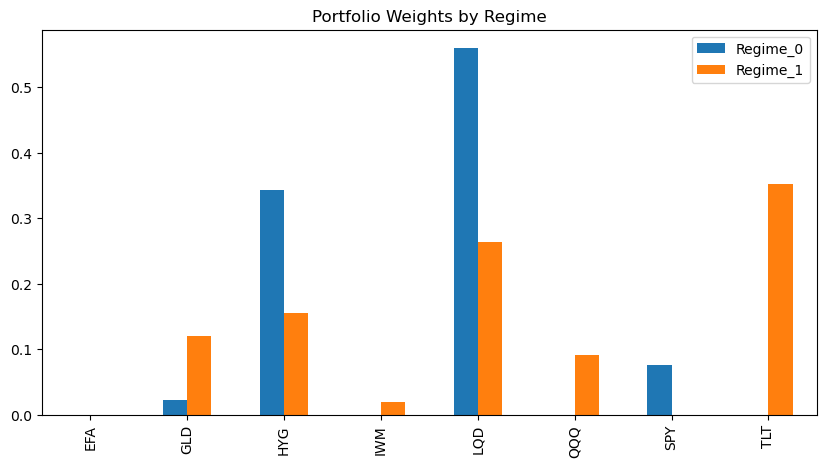

In [25]:
inWeightsDf.plot(kind="bar", figsize=(10, 5), title="Portfolio Weights by Regime")

In [24]:
inPortStats0 = portfolio_stats(inRegimeWeights0, retRegime0)
inPortStats1 = portfolio_stats(inRegimeWeights1, retRegime1)

statsDf = pd.DataFrame({
    "Regime_0": inPortStats0,
    "Regime_1": inPortStats1
})
statsDf

,Regime_0,Regime_1
mean_daily,0.000294,0.000246
vol_daily,0.002639,0.005695
mean_annual_approx,0.074079,0.061903
vol_annual_approx,0.041888,0.090405
sharpe_approx,1.768528,0.684734
